# Order Delivery Time Prediction

## Objectives
The objective of this assignment is to build a regression model that predicts the delivery time for orders placed through Porter. The model will use various features such as the items ordered, the restaurant location, the order protocol, and the availability of delivery partners.

The key goals are:
- Predict the delivery time for an order based on multiple input features
- Improve delivery time predictions to optimiae operational efficiency
- Understand the key factors influencing delivery time to enhance the model's accuracy

## Data Pipeline
The data pipeline for this assignment will involve the following steps:
1. **Data Loading**
2. **Data Preprocessing and Feature Engineering**
3. **Exploratory Data Analysis**
4. **Model Building**
5. **Model Inference**

## Data Understanding
The dataset contains information on orders placed through Porter, with the following columns:

| Field                     | Description                                                                                 |
|---------------------------|---------------------------------------------------------------------------------------------|
| market_id                 | Integer ID representing the market where the restaurant is located.                         |
| created_at                | Timestamp when the order was placed.                                                        |
| actual_delivery_time      | Timestamp when the order was delivered.                                                     |
| store_primary_category    | Category of the restaurant (e.g., fast food, dine-in).                                      |
| order_protocol            | Integer representing how the order was placed (e.g., via Porter, call to restaurant, etc.). |
| total_items               | Total number of items in the order.                                                         |
| subtotal                  | Final price of the order.                                                                   |
| num_distinct_items        | Number of distinct items in the order.                                                      |
| min_item_price            | Price of the cheapest item in the order.                                                    |
| max_item_price            | Price of the most expensive item in the order.                                              |
| total_onshift_dashers     | Number of delivery partners on duty when the order was placed.                              |
| total_busy_dashers        | Number of delivery partners already occupied with other orders.                             |
| total_outstanding_orders  | Number of orders pending fulfillment at the time of the order.                              |
| distance                  | Total distance from the restaurant to the customer.                                         |


## **Importing Necessary Libraries**

In [3]:
# Import essential libraries for data manipulation and analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split


## **1. Loading the data**
Load 'porter_data_1.csv' as a DataFrame

In [4]:
# Importing the file porter_data_1.csv
df = pd.read_csv('porter_data.csv')

In [5]:
df.head()

,market_id,created_at,actual_delivery_time,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_dashers,total_busy_dashers,total_outstanding_orders,distance
0,1.0,2015-02-06 22:24:17,2015-02-06 23:11:17,4,1.0,4,3441,4,557,1239,33.0,14.0,21.0,34.44
1,2.0,2015-02-10 21:49:25,2015-02-10 22:33:25,46,2.0,1,1900,1,1400,1400,1.0,2.0,2.0,27.60
2,2.0,2015-02-16 00:11:35,2015-02-16 01:06:35,36,3.0,4,4771,3,820,1604,8.0,6.0,18.0,11.56
3,1.0,2015-02-12 03:36:46,2015-02-12 04:35:46,38,1.0,1,1525,1,1525,1525,5.0,6.0,8.0,31.80
4,1.0,2015-01-27 02:12:36,2015-01-27 02:58:36,38,1.0,2,3620,2,1425,2195,5.0,5.0,7.0,8.20


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175777 entries, 0 to 175776
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   market_id                 175777 non-null  float64
 1   created_at                175777 non-null  object 
 2   actual_delivery_time      175777 non-null  object 
 3   store_primary_category    175777 non-null  int64  
 4   order_protocol            175777 non-null  float64
 5   total_items               175777 non-null  int64  
 6   subtotal                  175777 non-null  int64  
 7   num_distinct_items        175777 non-null  int64  
 8   min_item_price            175777 non-null  int64  
 9   max_item_price            175777 non-null  int64  
 10  total_onshift_dashers     175777 non-null  float64
 11  total_busy_dashers        175777 non-null  float64
 12  total_outstanding_orders  175777 non-null  float64
 13  distance                  175777 non-null  f

## **2. Data Preprocessing and Feature Engineering** <font color = red>[15 marks]</font> <br>

#### **2.1 Fixing the Datatypes**  <font color = red>[5 marks]</font> <br>
The current timestamps are in object format and need conversion to datetime format for easier handling and intended functionality

##### **2.1.1** <font color = red>[2 marks]</font> <br>
Convert date and time fields to appropriate data type

In [7]:
# Convert 'created_at' and 'actual_delivery_time' columns to datetime format
df['created_at'] = pd.to_datetime(df['created_at'])
df['actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])


##### **2.1.2**  <font color = red>[3 marks]</font> <br>
Convert categorical fields to appropriate data type

In [8]:
# Convert categorical features to category type
categorical_features = ['market_id', 'store_primary_category', 'order_protocol']
df[categorical_features] = df[categorical_features].astype('category')


#### **2.2 Feature Engineering** <font color = red>[5 marks]</font> <br>
Calculate the time taken to execute the delivery as well as extract the hour and day at which the order was placed

##### **2.2.1** <font color = red>[2 marks]</font> <br>
Calculate the time taken using the features `actual_delivery_time` and `created_at`

In [9]:
# Calculate time taken in minutes
df['delivery_time_taken'] = df['actual_delivery_time'] - df['created_at']
df['delivery_time_taken'] = df['delivery_time_taken'].dt.total_seconds() / 60

##### **2.2.2** <font color = red>[3 marks]</font> <br>
Extract the hour at which the order was placed and which day of the week it was. Drop the unnecessary columns.

In [10]:
# Extract the hour and day of week from the 'created_at' timestamp
df['hour'] = df['created_at'].dt.hour
df['day_of_week'] = df['created_at'].dt.dayofweek

# Create a categorical feature 'isWeekend'
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0).astype('category')

In [11]:
# Drop unnecessary columns
df.drop(columns=['created_at','actual_delivery_time'] , inplace = True)

#### **2.3 Creating training and validation sets** <font color = red>[5 marks]</font> <br>

##### **2.3.1** <font color = red>[2 marks]</font> <br>
 Define target and input features

In [12]:
# Define target variable (y) and features (X)
y = df.pop('delivery_time_taken')
X = df


##### **2.3.2** <font color = red>[3 marks]</font> <br>
 Split the data into training and test sets

In [13]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size = 0.7,random_state=25)


## **3. Exploratory Data Analysis on Training Data** <font color = red>[20 marks]</font> <br>
1. Analyzing the correlation between variables to identify patterns and relationships
2. Identifying and addressing outliers to ensure the integrity of the analysis
3. Exploring the relationships between variables and examining the distribution of the data for better insights

#### **3.1 Feature Distributions** <font color = red> [7 marks]</font> <br>


In [14]:
# Define numerical and categorical columns for easy EDA and data manipulation
categorical_cols = ['market_id','store_primary_category','order_protocol','is_weekend']
numerical_cols = ['total_items','num_distinct_items','min_item_price','max_item_price','subtotal','total_onshift_dashers','total_busy_dashers','total_outstanding_orders','distance','hour','day_of_week']

##### **3.1.1** <font color = red>[3 marks]</font> <br>
Plot distributions for numerical columns in the training set to understand their spread and any skewness

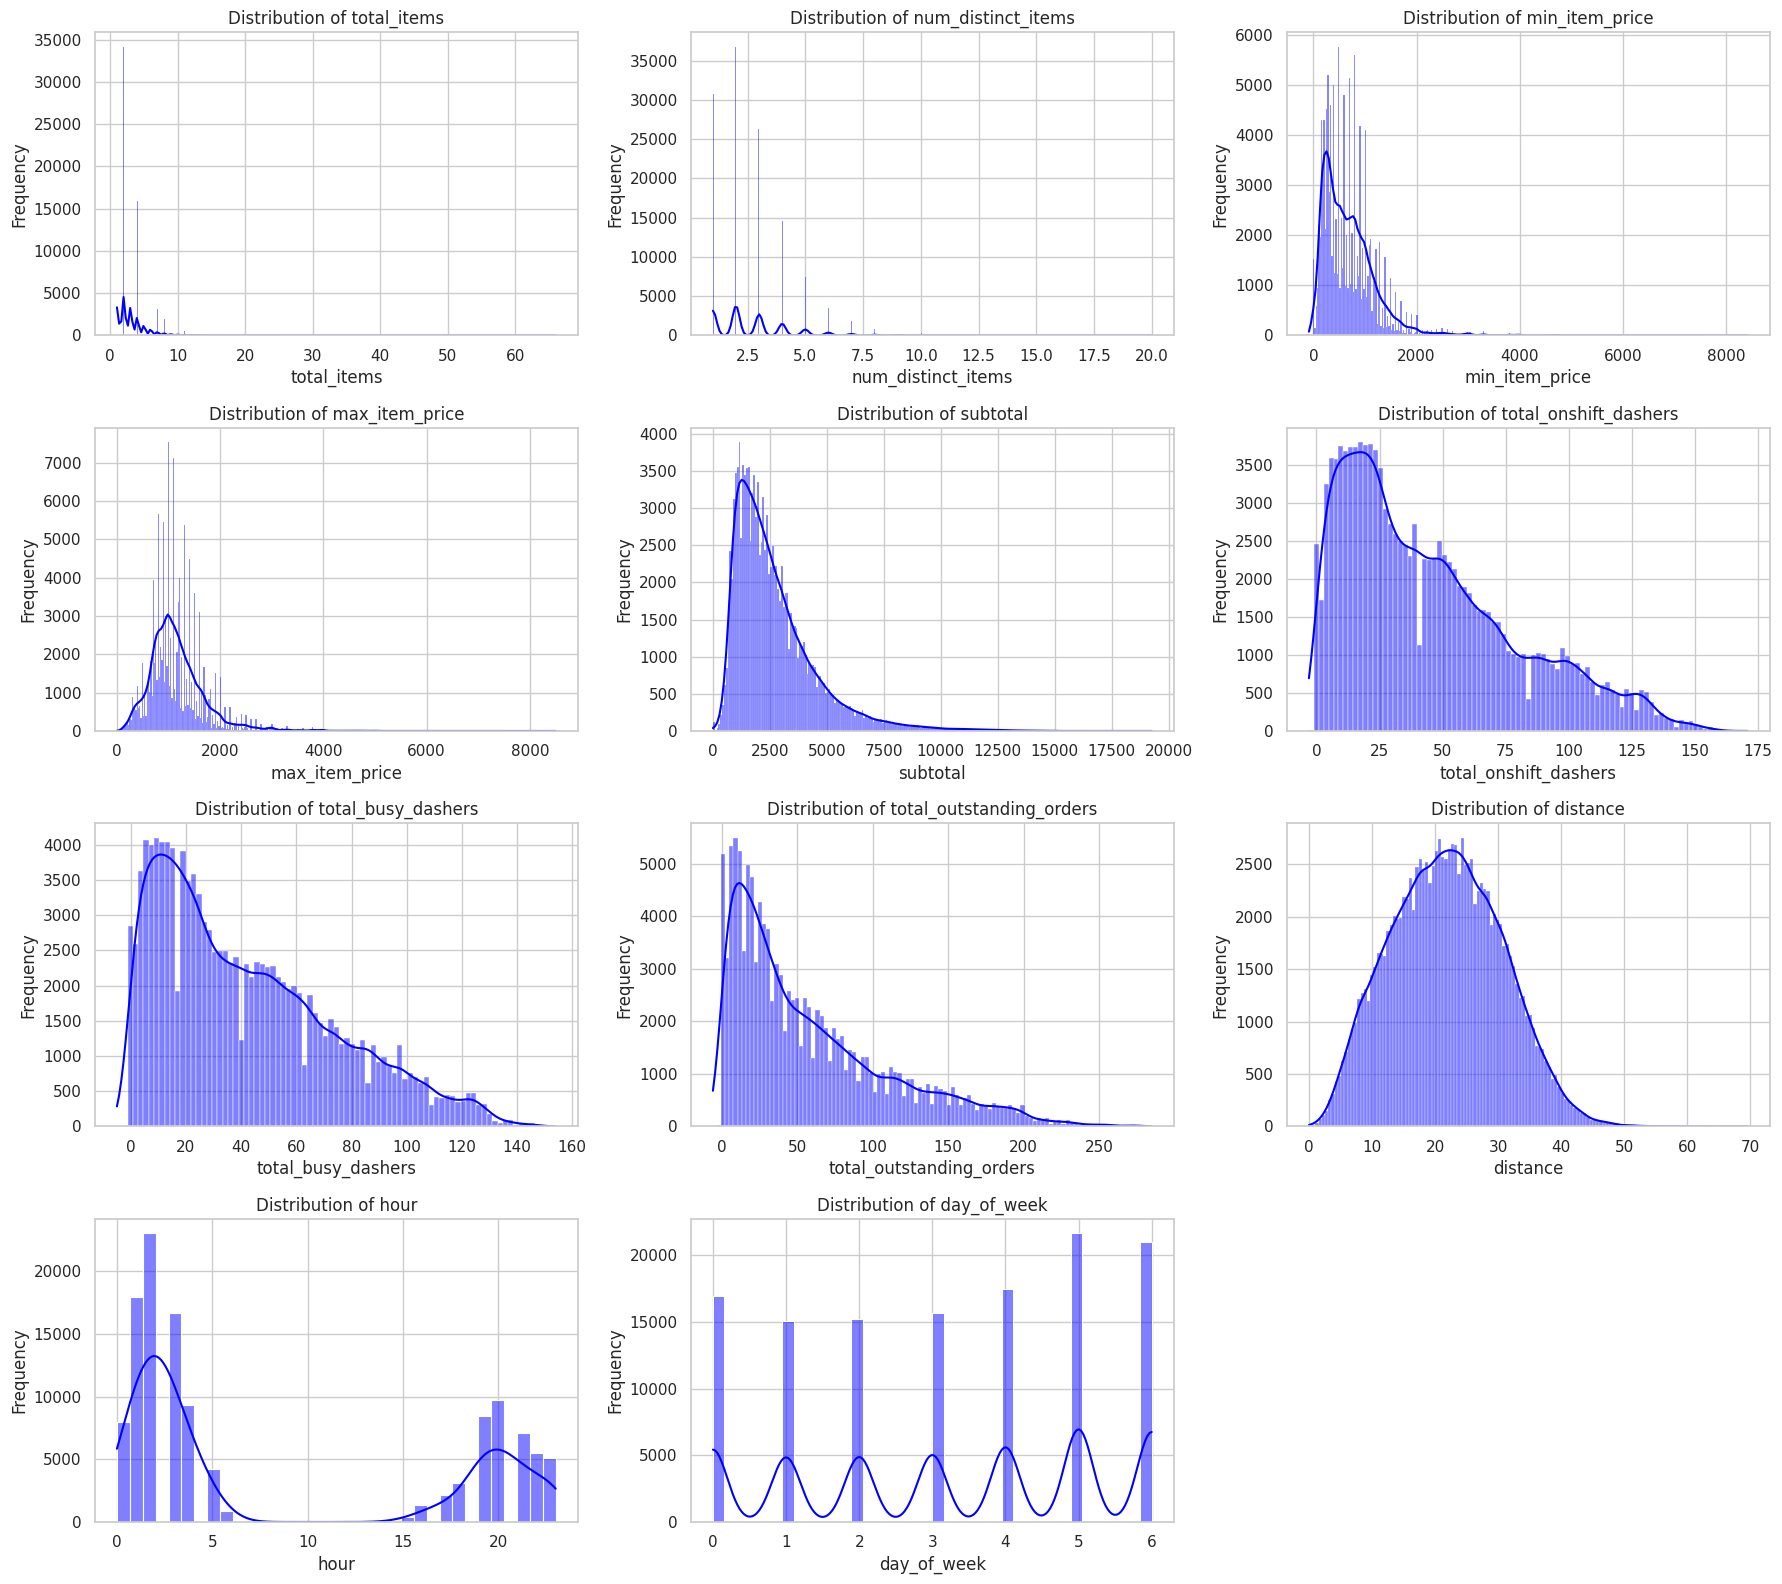

In [15]:
# Plot distributions for all numerical columns
plt.figure(figsize = (18,16))
sns.set(style="whitegrid")

# Create each subplot
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 3, i + 1)
    sns.histplot(X_train[col], kde=True, color='blue')
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


##### **3.1.2** <font color = red>[2 marks]</font> <br>
Check the distribution of categorical features

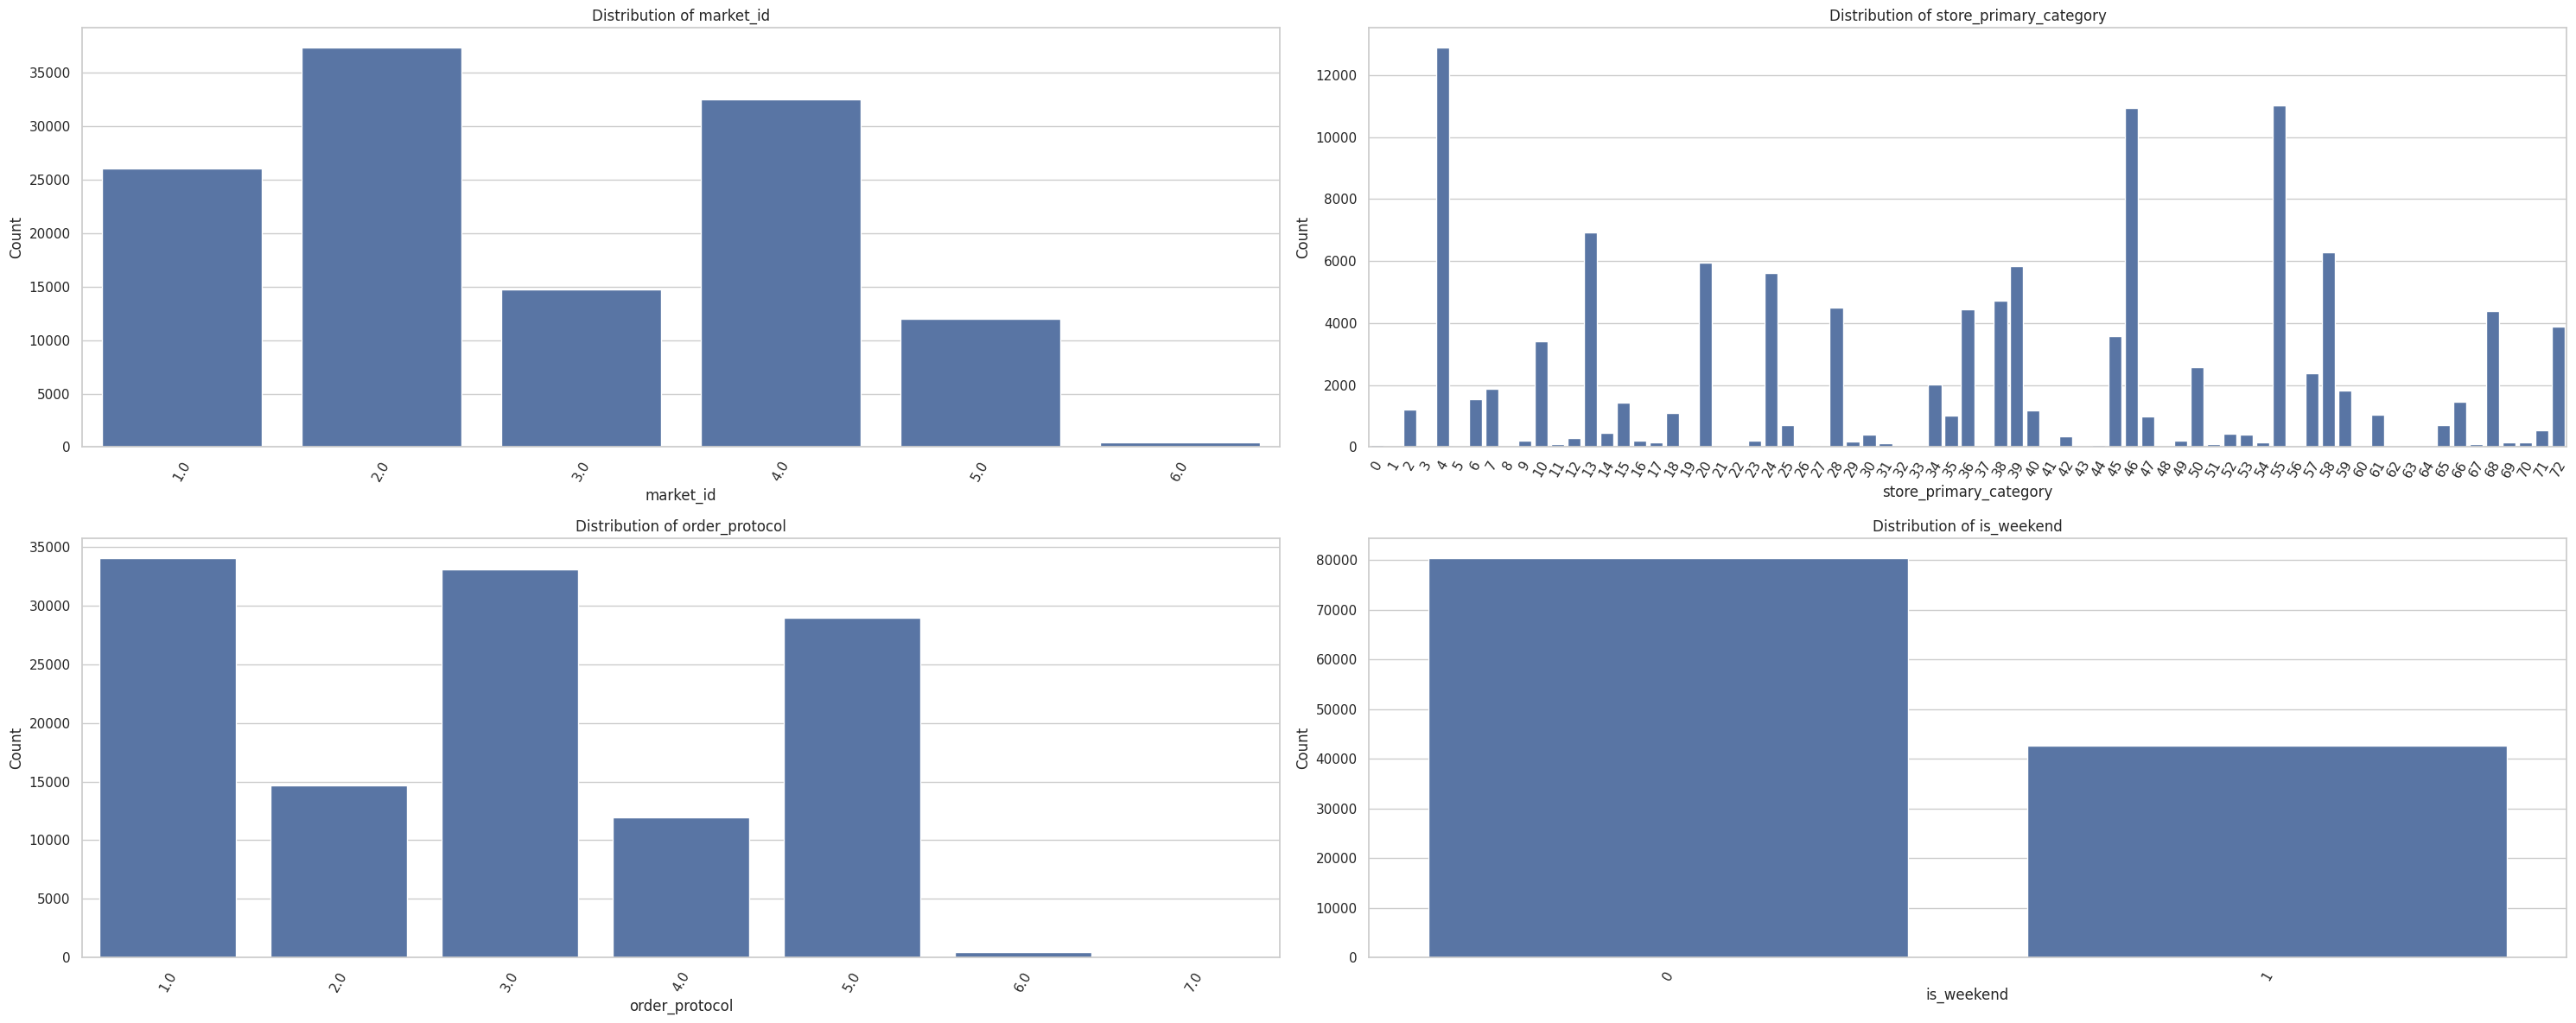

In [16]:
# Distribution of categorical columns
plt.figure(figsize = (30,12))
sns.set(style="whitegrid")

for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2 , i + 1)
    sns.countplot(data=X_train, x=col)
    plt.title(f'Distribution of {col}', fontsize=12)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

##### **3.1.3** <font color = red>[2 mark]</font> <br>
Visualise the distribution of the target variable to understand its spread and any skewness

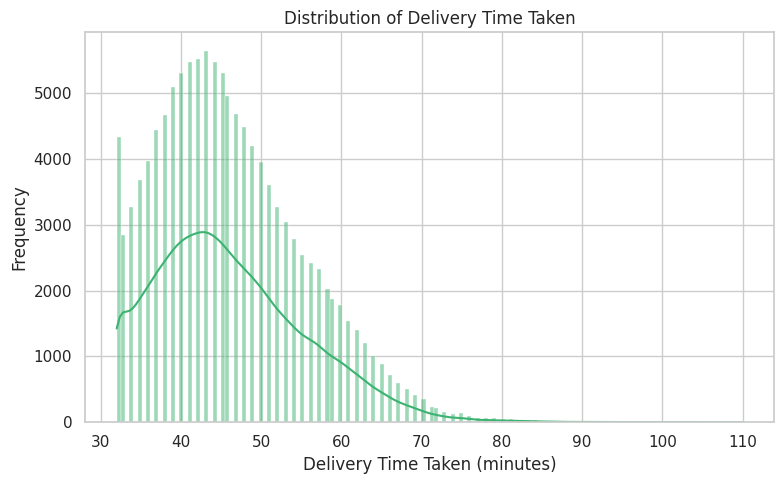

In [17]:
# Distribution of time_taken

plt.figure(figsize=(8, 5))
sns.set(style="whitegrid")
sns.histplot(y_train, kde=True, color='mediumseagreen')
plt.title('Distribution of Delivery Time Taken')
plt.xlabel('Delivery Time Taken (minutes)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()



#### **3.2 Relationships Between Features** <font color = red>[3 marks]</font> <br>

##### **3.2.1** <font color = red>[3 marks]</font> <br>
Scatter plots for important numerical and categorical features to observe how they relate to `time_taken`

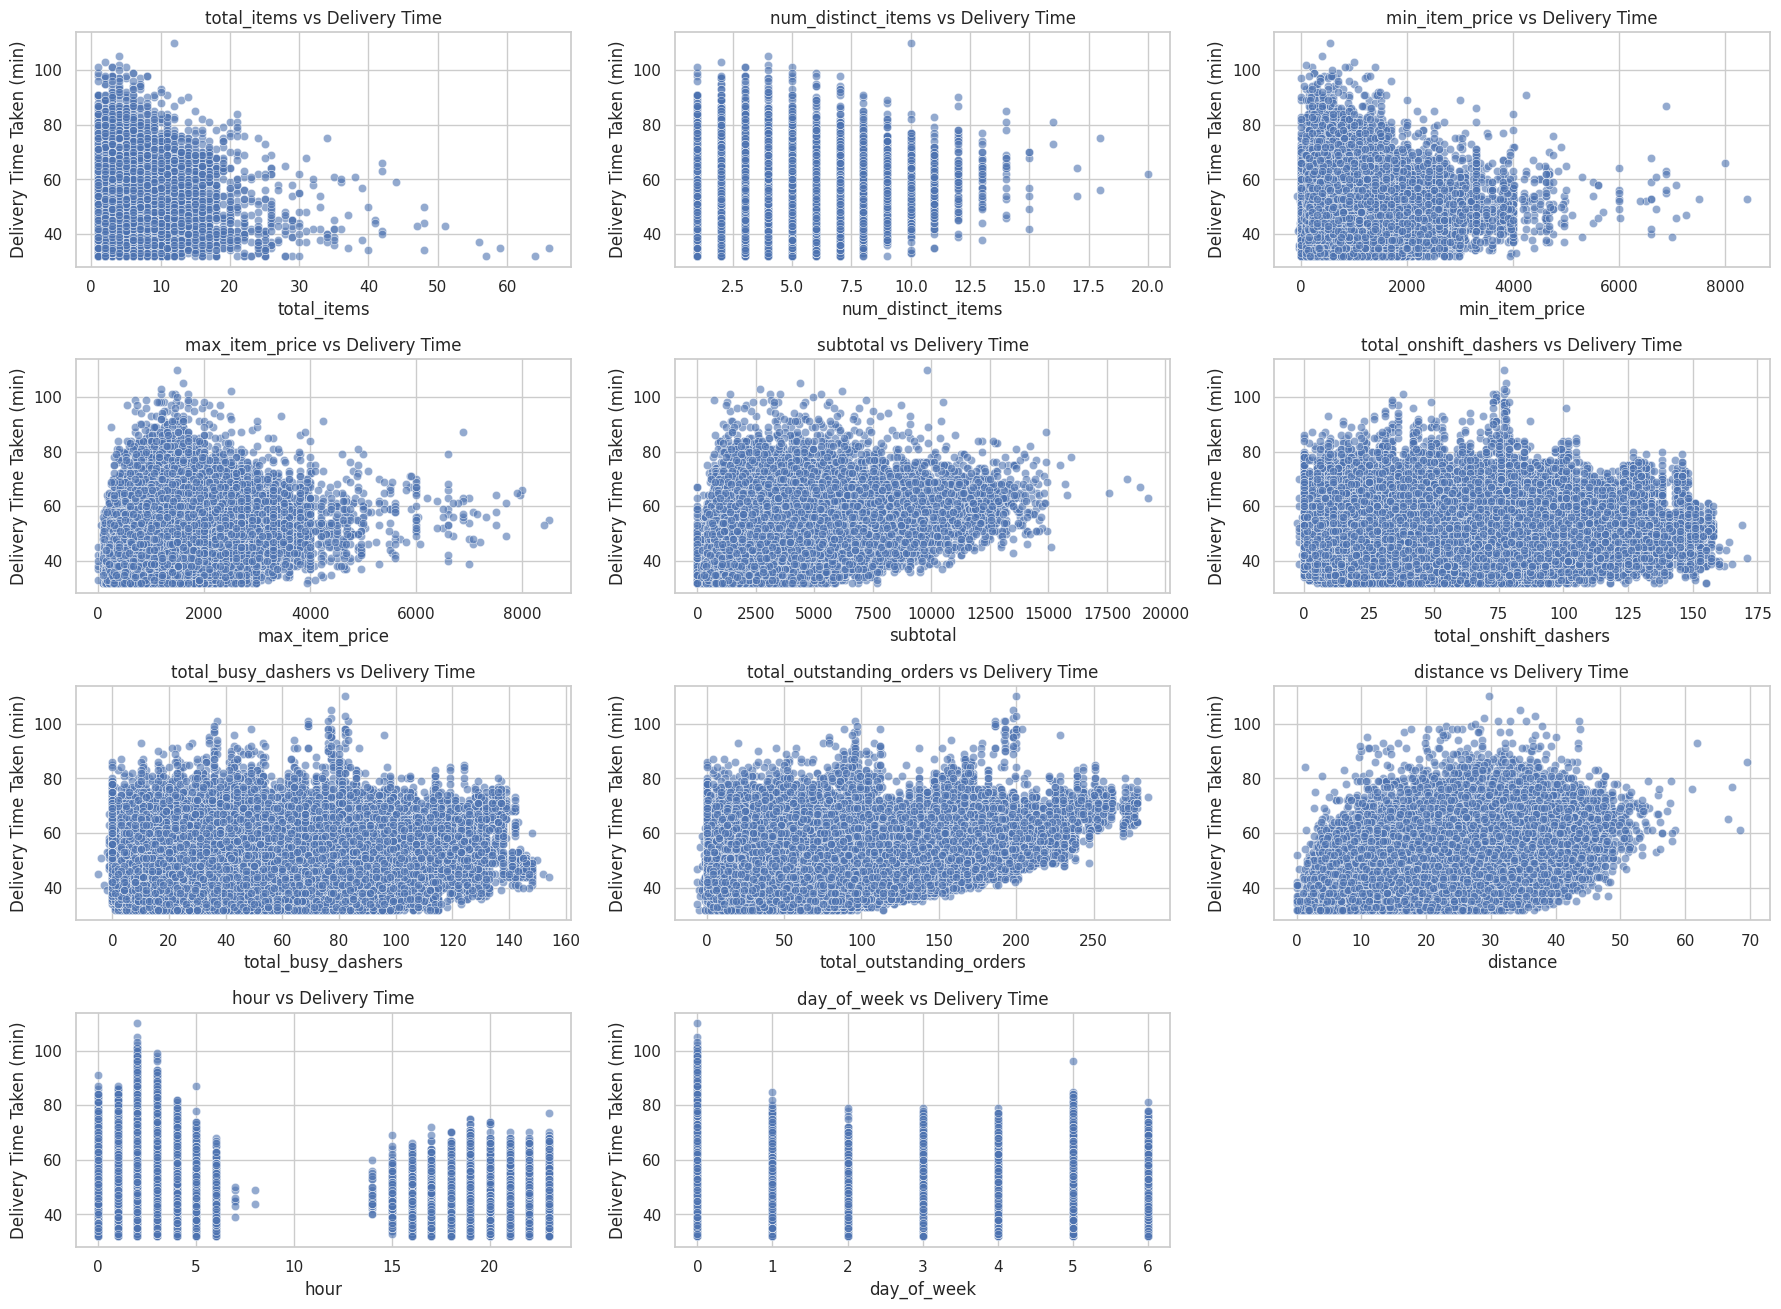

In [18]:
# Scatter plot to visualise the relationship between time_taken and other features

plt.figure(figsize=(18,16))
sns.set(style="whitegrid")

for i, col in enumerate(numerical_cols):
    plt.subplot(5, 3, i + 1)
    sns.scatterplot( x = X_train[col], y=y_train, alpha=0.6)
    plt.title(f'{col} vs Delivery Time')
    plt.xlabel(col)
    plt.ylabel('Delivery Time Taken (min)')

plt.tight_layout()
plt.show()


/tmp/ipython-input-19-3726850161.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=X_train['hour'], y=y_train, palette='coolwarm')


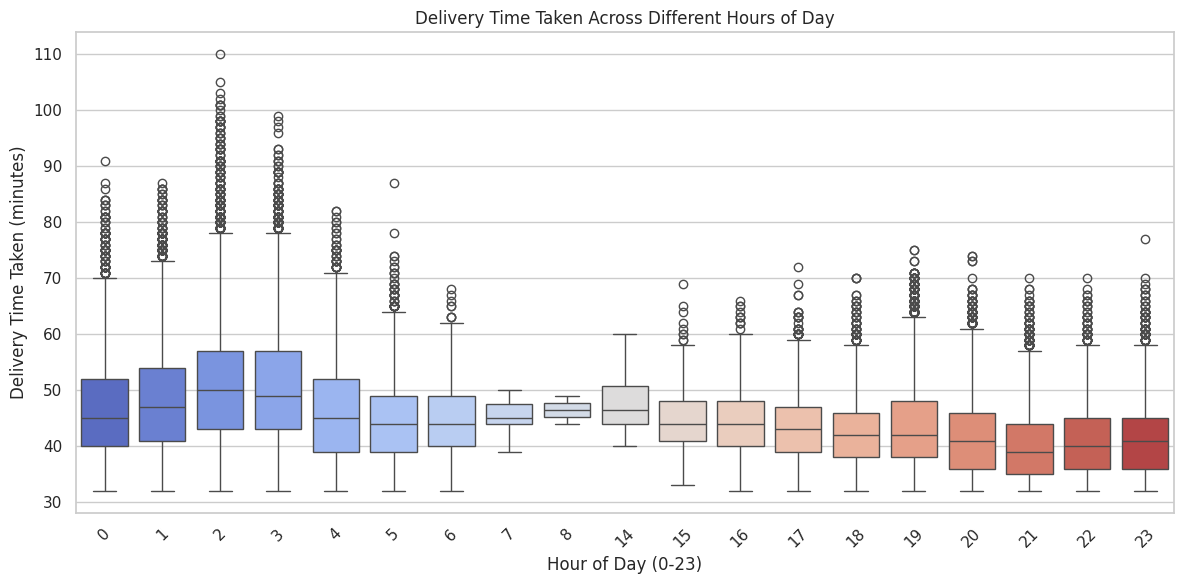

In [19]:
# Show the distribution of time_taken for different hours
plt.figure(figsize=(12, 6))
sns.boxplot(x=X_train['hour'], y=y_train, palette='coolwarm')
plt.title('Delivery Time Taken Across Different Hours of Day')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Delivery Time Taken (minutes)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### **3.3 Correlation Analysis** <font color = red>[5 marks]</font> <br>
Check correlations between numerical features to identify which variables are strongly related to `time_taken`

##### **3.3.1** <font color = red>[3 marks]</font> <br>
Plot a heatmap to display correlations

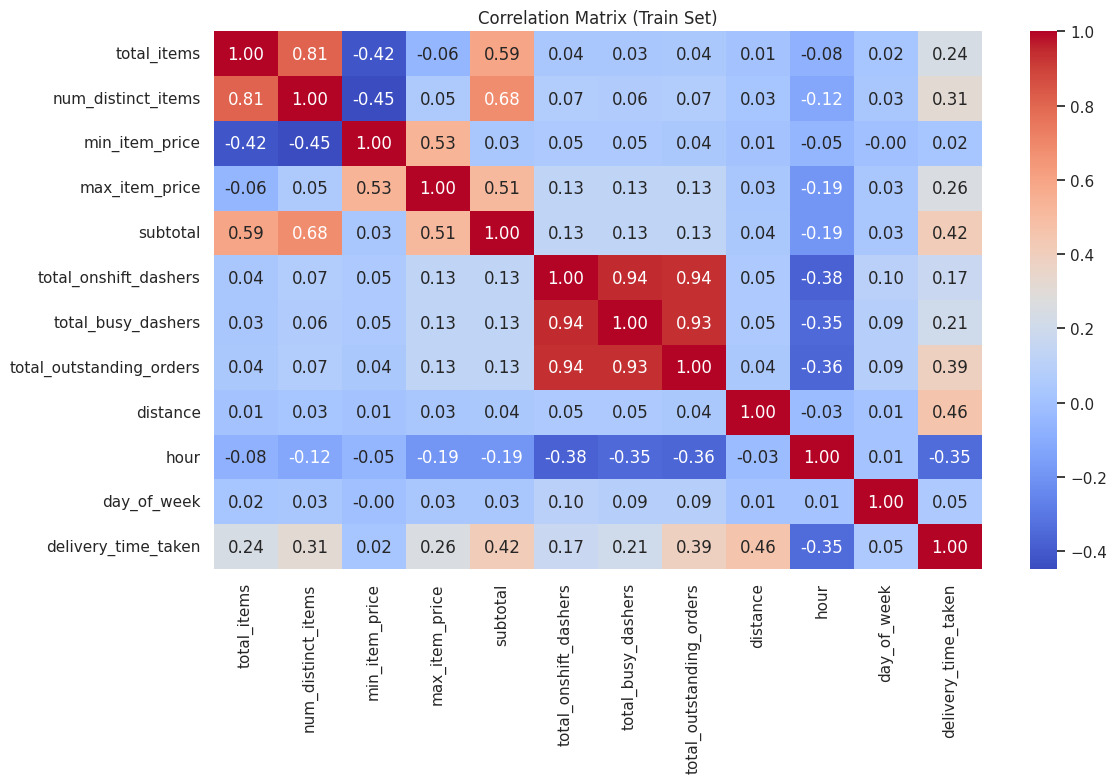

In [20]:
# Plot the heatmap of the correlation matrix
train_df = X_train.copy()
train_df['delivery_time_taken'] = y_train

num_cols_with_target = numerical_cols + ['delivery_time_taken']

corr_matrix = train_df[num_cols_with_target].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Train Set)')
plt.tight_layout()
plt.show()


##### **3.3.2** <font color = red>[2 marks]</font> <br>
Drop the columns with weak correlations with the target variable

In [21]:
# Drop 3-5 weakly correlated columns from training dataset
X_train.drop(columns = ['min_item_price','day_of_week','total_onshift_dashers','total_busy_dashers'],inplace = True)
X_test.drop(columns = ['min_item_price','day_of_week','total_onshift_dashers','total_busy_dashers'],inplace = True)
train_df.drop(columns = ['min_item_price','day_of_week','total_onshift_dashers','total_busy_dashers'],inplace = True)

#### **3.4 Handling the Outliers** <font color = red>[5 marks]</font> <br>



##### **3.4.1** <font color = red>[2 marks]</font> <br>
Visualise potential outliers for the target variable and other numerical features using boxplots

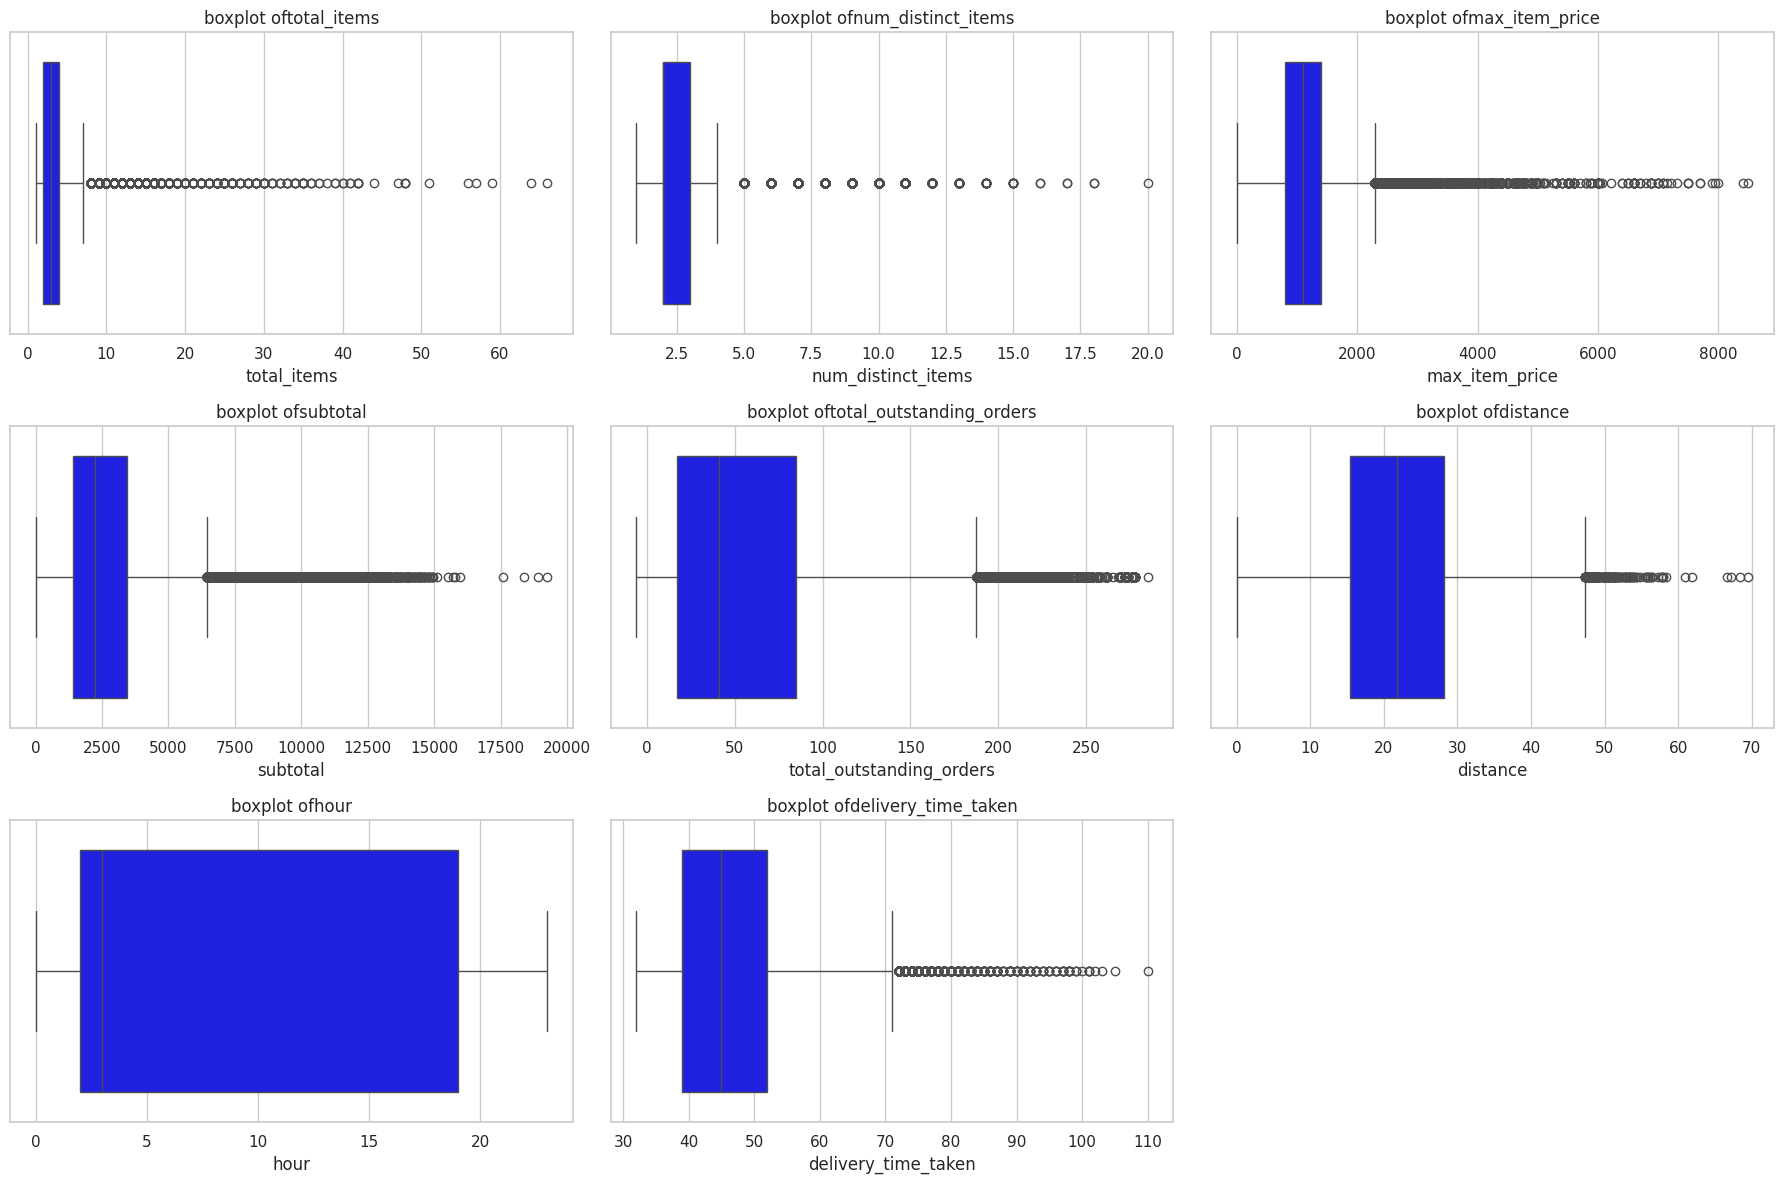

In [22]:
# Boxplot for time_taken
numerical_cols = ['total_items','num_distinct_items','max_item_price','subtotal','total_outstanding_orders','distance','hour']
num_cols_with_target = numerical_cols + ['delivery_time_taken']

plt.figure(figsize=(18,12))
sns.set(style="whitegrid")

for i,col in enumerate(num_cols_with_target):
  plt.subplot(3,3,i+1)
  sns.boxplot(x=train_df[col],color='Blue')
  plt.title(f'boxplot of{col}')
  plt.xlabel(col)

plt.tight_layout()
plt.show()


##### **3.4.2** <font color = red>[3 marks]</font> <br>
Handle outliers present in all columns

In [23]:
# Handle outliers
def cap_outliers_iqr(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    return df

X_train = cap_outliers_iqr(X_train,numerical_cols)
X_test = cap_outliers_iqr(X_test,numerical_cols)
train_df = cap_outliers_iqr(train_df,num_cols_with_target)
#for y
Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)
IQR = Q3 - Q1

y_train = y_train.clip(lower = Q1 - 1.5 * IQR, upper = Q3 + 1.5 * IQR)
y_test = y_test.clip(lower = Q1 - 1.5 * IQR, upper = Q3 + 1.5 * IQR)

## **4. Exploratory Data Analysis on Validation Data** <font color = red>[optional]</font> <br>
Optionally, perform EDA on test data to see if the distribution match with the training data

In [24]:
# Define numerical and categorical columns for easy EDA and data manipulation



#### **4.1 Feature Distributions**


##### **4.1.1**
Plot distributions for numerical columns in the validation set to understand their spread and any skewness

In [25]:
# Plot distributions for all numerical columns



##### **4.1.2**
Check the distribution of categorical features

In [26]:
# Distribution of categorical columns



##### **4.1.3**
Visualise the distribution of the target variable to understand its spread and any skewness

In [27]:
# Distribution of time_taken



#### **4.2 Relationships Between Features**
Scatter plots for numerical features to observe how they relate to each other, especially to `time_taken`

In [28]:
# Scatter plot to visualise the relationship between time_taken and other features



#### **4.3** Drop the columns with weak correlations with the target variable

In [29]:
# Drop the weakly correlated columns from training dataset



## **5. Model Building** <font color = red>[15 marks]</font> <br>

#### **Import Necessary Libraries**

In [30]:
# Import libraries
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE

#### **5.1 Feature Scaling** <font color = red>[3 marks]</font> <br>

In [31]:
# Apply scaling to the numerical columns
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])

X_test_scaled = X_test.copy()
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])


Note that linear regression is agnostic to feature scaling. However, with feature scaling, we get the coefficients to be somewhat on the same scale so that it becomes easier to compare them.

#### **5.2 Build a linear regression model** <font color = red>[5 marks]</font> <br>

You can choose from the libraries *statsmodels* and *scikit-learn* to build the model.

In [32]:
# Create/Initialise the model
X_train_scaled_sm = sm.add_constant(X_train_scaled)


In [33]:
# Train the model using the training data
model = sm.OLS(y_train,X_train_scaled_sm)
LR_model = model.fit()
LR_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     delivery_time_taken   R-squared:                       0.538
Model:                             OLS   Adj. R-squared:                  0.538
Method:                  Least Squares   F-statistic:                 1.302e+04
Date:                 Sat, 12 Jul 2025   Prob (F-statistic):               0.00
Time:                         10:01:10   Log-Likelihood:            -3.9918e+05
No. Observations:               123043   AIC:                         7.984e+05
Df Residuals:                   123031   BIC:                         7.985e+05
Df Model:                           11                                         
Covariance Type:             nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       50.0828      0.062    806.671      0.000      49.961      50.204
market_id                   -0.6971      0.013    -52.217      0.000      -0.723      -0.671
store_primary_category       0.0021      0.001      2.465      0.014       0.000       0.004
order_protocol              -0.9263      0.012    -77.497      0.000      -0.950      -0.903
total_items                  0.3063      0.045      6.813      0.000       0.218       0.394
subtotal                     2.3281      0.038     61.502      0.000       2.254       2.402
num_distinct_items           0.3388      0.038      8.953      0.000       0.265       0.413
max_item_price               0.1104      0.028      3.896      0.000       0.055       0.166
total_outstanding_orders     2.4731      0.020    126.139      0.000       2.435       2.512
distance                     3.9889      0.018    225.067      0.000       3.954       4.024
hour                        -1.5467      0.019    -79.397      0.000      -1.585      -1.509
is_weekend                   1.7417      0.037     46.448      0.000       1.668       1.815
==============================================================================
Omnibus:                     2499.241   Durbin-Watson:                   1.996
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2811.444
Skew:                           0.317   Prob(JB):                         0.00
Kurtosis:                       3.383   Cond. No.                         150.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [34]:
# Make predictions
X_test_scaled_sm = sm.add_constant(X_test_scaled)
y_train_pred = LR_model.predict(X_train_scaled_sm)
y_test_pred = LR_model.predict(X_test_scaled_sm)



In [35]:
# Find results for evaluation metrics
r2 =r2_score(y_test,y_test_pred)
print(r2)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print(rmse)

0.53581768792675
6.215055923344711


Note that we have 12 (depending on how you select features) training features. However, not all of them would be useful. Let's say we want to take the most relevant 8 features.

We will use Recursive Feature Elimination (RFE) here.

For this, you can look at the coefficients / p-values of features from the model summary and perform feature elimination, or you can use the RFE module provided with *scikit-learn*.

#### **5.3 Build the model and fit RFE to select the most important features** <font color = red>[7 marks]</font> <br>

For RFE, we will start with all features and use
the RFE method to recursively reduce the number of features one-by-one.

After analysing the results of these iterations, we select the one that has a good balance between performance and number of features.

In [36]:
# Loop through the number of features and test the model
lr = LinearRegression()

for i in range(1,12):
  rfe = RFE(estimator=lr,n_features_to_select=i)
  rfe.fit(X_train_scaled,y_train)

  selected_features = X_train_scaled.columns[rfe.support_]
  lr.fit(X_train_scaled[selected_features],y_train)

  y_pred=lr.predict(X_test_scaled[selected_features])
  r2 = r2_score(y_test,y_pred)
  rmse = np.sqrt(mean_squared_error(y_test,y_pred))

  print(f'number of features-{i}, r2={r2}, rmse={rmse}')


number of features-1, r2=0.211993931959631, rmse=8.097771689235225
number of features-2, r2=0.37200024898414585, rmse=7.2290375874536945
number of features-3, r2=0.46373189038390916, rmse=6.680234881305012
number of features-4, r2=0.4706208182228603, rmse=6.6371888704537305
number of features-5, r2=0.49987771475656073, rmse=6.451175408278627
number of features-6, r2=0.5225157772827417, rmse=6.303478270781311
number of features-7, r2=0.5330537500064265, rmse=6.233531997112759
number of features-8, r2=0.5359418256227312, rmse=6.214224812063411
number of features-9, r2=0.535733479309461, rmse=6.2156196431570665
number of features-10, r2=0.5357527959447042, rmse=6.2154903358508
number of features-11, r2=0.5358176879267502, rmse=6.215055923344709


In [37]:
# Build the final model with selected number of features
rfe = RFE(estimator=lr,n_features_to_select=8)
rfe.fit(X_train_scaled,y_train)

selected_features =X_train_scaled.columns[rfe.support_]
lr.fit(X_train_scaled[selected_features],y_train)

y_pred = lr.predict(X_test_scaled[selected_features])

r2 = r2_score(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print(f'features selected - {selected_features}')
print(f'r2 = {r2}, rmse = {rmse}')

features selected - Index(['market_id', 'order_protocol', 'subtotal', 'num_distinct_items',
       'total_outstanding_orders', 'distance', 'hour', 'is_weekend'],
      dtype='object')
r2 = 0.5359418256227312, rmse = 6.214224812063411


## **6. Results and Inference** <font color = red>[5 marks]</font> <br>

#### **6.1 Perform Residual Analysis** <font color = red>[3 marks]</font> <br>

Text(0.5, 1.0, 'Q-Q plot of residuals')

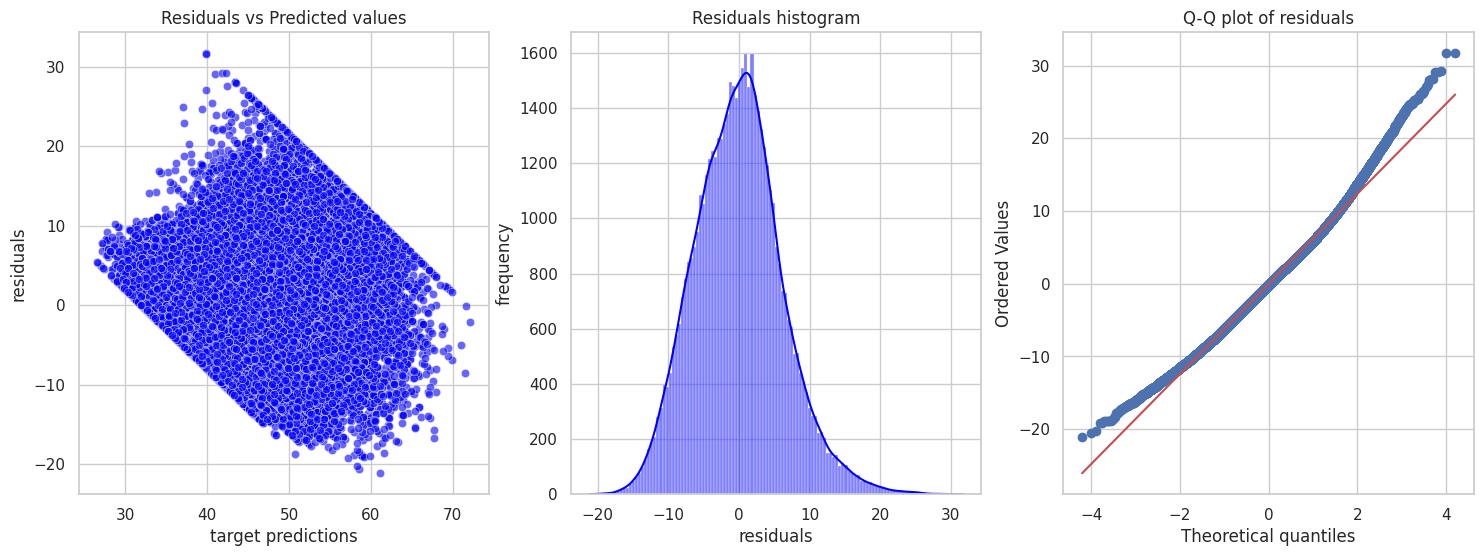

In [38]:
# Perform residual analysis using plots like residuals vs predicted values, Q-Q plot and residual histogram
residuals = y_test - y_pred

plt.figure(figsize=(18,6))
plt.subplot(1,3,1)
sns.scatterplot(x=y_pred, y=residuals,alpha=0.6, color='Blue')
plt.title('Residuals vs Predicted values')
plt.xlabel('target predictions')
plt.ylabel('residuals')

plt.subplot(1,3,2)
sns.histplot(residuals,kde=True,color='Blue')
plt.title('Residuals histogram')
plt.xlabel('residuals')
plt.ylabel('frequency')

plt.subplot(1,3,3)
stats.probplot(residuals,dist='norm', plot=plt)
plt.title('Q-Q plot of residuals')


[Your inferences here:]



#### **6.2 Perform Coefficient Analysis** <font color = red>[2 marks]</font> <br>

Perform coefficient analysis to find how changes in features affect the target.
Also, the features were scaled, so interpret the scaled and unscaled coefficients to understand the impact of feature changes on delivery time.


In [39]:
# Compare the scaled vs unscaled features used in the final model
scaled_coefs = pd.Series(lr.coef_, index=selected_features)

lr_unscaled = LinearRegression()
lr_unscaled.fit(X_train[selected_features],y_train)
unscaled_coefs = pd.Series(lr_unscaled.coef_,index=selected_features)

coef_comparison = pd.DataFrame({'scaled':scaled_coefs,'unscaled':unscaled_coefs})
coef_comparison


,scaled,unscaled
market_id,-0.696058,-0.696058
order_protocol,-0.923479,-0.923479
subtotal,2.482707,0.001613
num_distinct_items,0.515187,0.430227
total_outstanding_orders,2.475208,0.048720
distance,3.987181,0.456231
hour,-1.547399,-0.178464
is_weekend,1.740387,1.740387


Additionally, we can analyse the effect of a unit change in a feature. In other words, because we have scaled the features, a unit change in the features will not translate directly to the model. Use scaled and unscaled coefficients to find how will a unit change in a feature affect the target.

In [47]:
# Analyze the effect of a unit change in a feature, say 'total_items'

scaled_coef_total_items = LR_model.params['total_items']
std_total_items = X_train['total_items'].std()  # unscaled X_train
effect = scaled_coef_total_items * std_total_items

print(f"A unit increase in 'total_items' affects delivery time by {effect:.2f} minutes.")


A unit increase in 'total_items' affects delivery time by 0.54 minutes.


Note:
The coefficients on the original scale might differ greatly in magnitude from the scaled coefficients, but they both describe the same relationships between variables.

Interpretation is key: Focus on the direction and magnitude of the coefficients on the original scale to understand the impact of each variable on the response variable in the original units.

Include conclusions in your report document.

## Subjective Questions <font color = red>[20 marks]</font>

Answer the following questions only in the notebook. Include the visualisations/methodologies/insights/outcomes from all the above steps in your report.

#### Subjective Questions based on Assignment

##### **Question 1.** <font color = red>[2 marks]</font> <br>

Are there any categorical variables in the data? From your analysis of the categorical variables from the dataset, what could you infer about their effect on the dependent variable?

**Answer:**
###Yes there are 4 categorical variables in our dataset:

###market_id- In our model it had a negative coefficient ,which could mean certain markets have a shorter delivery times than others.

###store_primary_category - This variable had many unique values and because of its high cardinality it was not useful in the model.

###order_protocol - In our model this variable had a negative coefficient , which suggests that some order methods may be faster than others.

###is_weekend - In our model this variable had a positive and significant coefficient indicating longer delivery times on weekend due to high demand or traffic.




---



##### **Question 2.** <font color = red>[1 marks]</font> <br>
What does `test_size = 0.2` refer to during splitting the data into training and test sets?

**Answer:**
### 'test_size = 0.2' means that we have splitted our data in a way that 80% of the data will be used for training and 20% of the data will be used for testing.




---



##### **Question 3.** <font color = red>[1 marks]</font> <br>
Looking at the heatmap, which one has the highest correlation with the target variable?  

**Answer:**
### Distance has the highest correlation of 0.46 with the target variable.




---



##### **Question 4.** <font color = red>[2 marks]</font> <br>
What was your approach to detect the outliers? How did you address them?

**Answer:**

###  I used boxplots to visualize the numerical features and to detect the outliers.To handle the outliers i capped them based on the IQR method




---



##### **Question 5.** <font color = red>[2 marks]</font> <br>
Based on the final model, which are the top 3 features significantly affecting the delivery time?

**Answer:**
### Based on the final model the top 3 features are distance , is_weekend and num_distinct_items



---



#### General Subjective Questions

##### **Question 6.** <font color = red>[3 marks]</font> <br>
Explain the linear regression algorithm in detail

**Answer:**
### Linear Regression is a supervised learning algorithm used for predicting a continuous numeric value based on one or more input features.It assumes a linear relationship between the independent variables and the dependent variable.The model tries to fit a straight line or a hyperplane that best predicts the target variable.

###The formula for linear regression is Y = a + b1 X1 + b2 X2 + … + bnXn
### Linear regression tries to find the best value for b1,b2,bn  by minimizing the difference between actual and predicted values for the target variable.this difference is measured by mean square error and the goal is to minimize the ean squared error to find the line that best fits the data






---



##### **Question 7.** <font color = red>[2 marks]</font> <br>
Explain the difference between simple linear regression and multiple linear regression

**Answer:**
### Simple linear regression involves only one independent variable and one dependent variable and models a straight line relationship between them ,whereas Multiple linear regression involves two or more independent variable to predict the dependent variable and models a hyperplane in the multidimensional space



---



##### **Question 8.** <font color = red>[2 marks]</font> <br>
What is the role of the cost function in linear regression, and how is it minimized?

**Answer:**
### The cost function in linear regression measures how well the model's predictions match the actual values.In linear regression we use mean squared error as the cost function and it is minimized by using methods such as Gradient descent.The algorithm adjusts the coefficients to reduce the cost step by step.






---



##### **Question 9.** <font color = red>[2 marks]</font> <br>
Explain the difference between overfitting and underfitting.



**Answer:**

### In the case of Overfitting the model learns the training data too well, including noise and outliers. It performs very well on training data but poorly on testing data.whereas In the case of Underfitting The model is too simple to capture the underlying patterns in the data and performs poorly on both training and test data.



---



##### **Question 10.** <font color = red>[3 marks]</font> <br>
How do residual plots help in diagnosing a linear regression model?

**Answer:**
###A residual plot shows residuals(the difference between the actual values and the predicted values for the target variable) on the y-axis and the predicted value on the x-axis.It helps visualize how well the model fits the data. it allows us to check for linearity and heteroscedasticity .  a residual plot should be centered around zero , residuals should be randomly scattered and there should be no obvious pattern.
